# Ensemble (XGBoost Improved + Neural Network)

In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn import metrics
import torch
import torch.nn as nn

### Load Data

In [2]:
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')
test_ids = test_df['id'].copy()

print(f'Train shape: {train_df.shape}')
print(f'Test shape: {test_df.shape}')

Train shape: (630000, 13)
Test shape: (270000, 12)


### Preprocess

In [3]:
# --- XGBoost pipeline: LabelEncoder on categoricals ---
xgb_train = train_df.copy()
xgb_test = test_df.copy()

categorical_cols = ['gender', 'course', 'internet_access', 'sleep_quality',
                    'study_method', 'facility_rating', 'exam_difficulty']

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    combined = pd.concat([xgb_train[col], xgb_test[col]], axis=0).astype(str)
    le.fit(combined)
    xgb_train[col] = le.transform(xgb_train[col].astype(str))
    xgb_test[col] = le.transform(xgb_test[col].astype(str))
    label_encoders[col] = le

xgb_feature_cols = [c for c in xgb_train.columns if c not in ['id', 'exam_score']]
X_xgb = xgb_train[xgb_feature_cols]
y = xgb_train['exam_score']
X_xgb_sub = xgb_test[xgb_feature_cols]

print(f'XGBoost features: {xgb_feature_cols}')

XGBoost features: ['age', 'gender', 'course', 'study_hours', 'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']


In [4]:
# --- NN pipeline: OrdinalEncoder + StandardScaler ---
nn_train = train_df.drop(columns=['id']).copy()
nn_test = test_df.drop(columns=['id']).copy()

cat_cols = ['gender', 'course', 'internet_access',
            'sleep_quality', 'study_method',
            'facility_rating', 'exam_difficulty']
num_cols = ['age', 'study_hours', 'class_attendance', 'sleep_hours']

oe = OrdinalEncoder()
nn_train[cat_cols] = oe.fit_transform(nn_train[cat_cols])
nn_test[cat_cols] = oe.transform(nn_test[cat_cols])

scaler = StandardScaler()
nn_train[num_cols] = scaler.fit_transform(nn_train[num_cols])
nn_test[num_cols] = scaler.transform(nn_test[num_cols])

X_nn_cat = torch.tensor(nn_train[cat_cols].to_numpy(), dtype=torch.long)
X_nn_num = torch.tensor(nn_train[num_cols].to_numpy(), dtype=torch.float32)

X_nn_sub_cat = torch.tensor(nn_test[cat_cols].to_numpy(), dtype=torch.long)
X_nn_sub_num = torch.tensor(nn_test[num_cols].to_numpy(), dtype=torch.float32)

print(f'NN cat tensor: {X_nn_cat.shape}, NN num tensor: {X_nn_num.shape}')

NN cat tensor: torch.Size([630000, 7]), NN num tensor: torch.Size([630000, 4])


### Train/Validation Split

In [5]:
indices = np.arange(len(train_df))
train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42)

# XGBoost validation data
X_xgb_val = X_xgb.iloc[val_idx]

# NN validation data
X_nn_cat_val = X_nn_cat[val_idx]
X_nn_num_val = X_nn_num[val_idx]

y_val = y.iloc[val_idx].to_numpy()

print(f'Validation size: {len(val_idx)}')

Validation size: 126000


### Load Pretrained Models

In [6]:
xgb_model = joblib.load('../models/xgboost_improved.pkl')
print(f'XGBoost model loaded (best iteration: {xgb_model.best_iteration})')

XGBoost model loaded (best iteration: 998)


In [7]:
class StudentScoreNet(nn.Module):
    def __init__(self, cat_features, cat_dims, emb_dims, num_numeric, num_output=1, dropout=0.15):
        super().__init__()

        self.embeddings = nn.ModuleList([
            nn.Embedding(num_categories, emb_dim)
            for num_categories, emb_dim in zip(cat_dims, emb_dims)
        ])

        total_emb_dim = sum(emb_dims)
        concat_dim = total_emb_dim + num_numeric

        self.dense = nn.Sequential(
            nn.Linear(concat_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.01),
            nn.Dropout(dropout),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.01),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.01),
            nn.Dropout(dropout),

            nn.Linear(64, num_output)
        )

    def forward(self, x_cat, x_num):
        embs = [
            emb_layer(x_cat[:, i])
            for i, emb_layer in enumerate(self.embeddings)
        ]
        x = torch.cat(embs + [x_num], dim=1)
        return self.dense(x)


cat_features = ['gender', 'course', 'internet_access',
                'sleep_quality', 'study_method',
                'facility_rating', 'exam_difficulty']
cat_dims = [3, 7, 2, 3, 5, 3, 3]
emb_dims = [2, 4, 2, 2, 3, 2, 2]
num_numeric = 4
num_output = 1

nn_model = StudentScoreNet(cat_features, cat_dims, emb_dims, num_numeric, num_output)
nn_model.load_state_dict(torch.load('../models/neural_network_linear_embedded.pt', weights_only=True))
nn_model.eval()
print(f'NN model loaded ({sum(p.numel() for p in nn_model.parameters()):,} parameters)')

NN model loaded (47,816 parameters)


### Tune Ensemble Weights

Best weight: 0.897 (XGB) / 0.103 (NN)
Best ensemble RMSE: 8.7399
XGBoost-only RMSE:  8.7413
NN-only RMSE:       8.8431


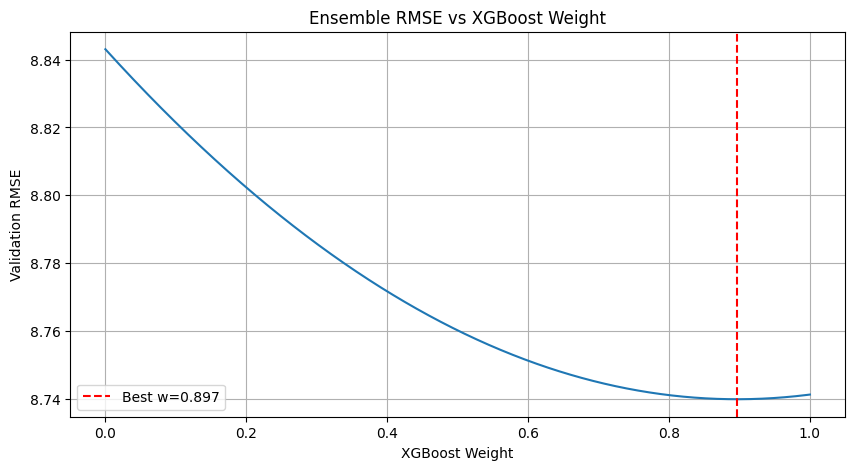

In [8]:
# Generate validation predictions from both models
xgb_val_preds = xgb_model.predict(X_xgb_val)

with torch.no_grad():
    nn_val_preds = nn_model(X_nn_cat_val, X_nn_num_val).numpy().flatten()

# Grid search over blending weight (finer step = 0.001, 1001 weights)
weights = np.arange(0.0, 1.0001, 0.001)
rmses = []
for w in weights:
    ensemble_preds = w * xgb_val_preds + (1 - w) * nn_val_preds
    rmse = np.sqrt(metrics.mean_squared_error(y_val, ensemble_preds))
    rmses.append(rmse)

best_idx = np.argmin(rmses)
best_w = weights[best_idx]
best_rmse = rmses[best_idx]

print(f'Best weight: {best_w:.3f} (XGB) / {1 - best_w:.3f} (NN)')
print(f'Best ensemble RMSE: {best_rmse:.4f}')
print(f'XGBoost-only RMSE:  {rmses[-1]:.4f}')
print(f'NN-only RMSE:       {rmses[0]:.4f}')

plt.figure(figsize=(10, 5))
plt.plot(weights, rmses)
plt.xlabel('XGBoost Weight')
plt.ylabel('Validation RMSE')
plt.title('Ensemble RMSE vs XGBoost Weight')
plt.axvline(x=best_w, color='r', linestyle='--', label=f'Best w={best_w:.3f}')
plt.legend()
plt.grid(True)
plt.show()

### Evaluate

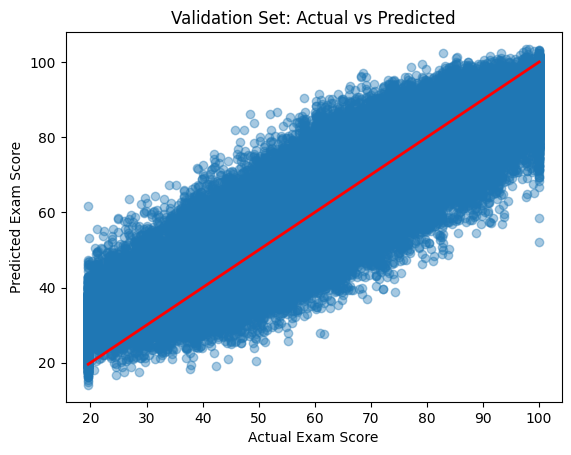

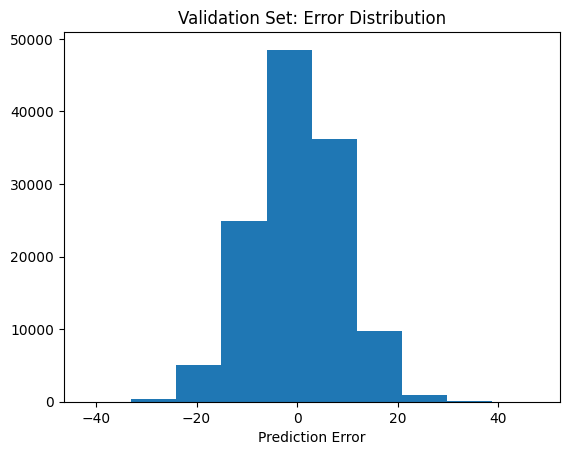

Metrics saved to ../metrics/ensemble_metrics.csv


,MAE,MSE,RMSE,R2
0,6.968196,76.385669,8.739890,0.785221


In [9]:
# Apply best weight to validation predictions
y_val_pred = best_w * xgb_val_preds + (1 - best_w) * nn_val_preds

# Actual vs Predicted
plt.scatter(y_val, y_val_pred, alpha=0.4)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r', lw=2)
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title('Validation Set: Actual vs Predicted')
plt.show()

# Error distribution
plt.hist(y_val - y_val_pred)
plt.xlabel('Prediction Error')
plt.title('Validation Set: Error Distribution')
plt.show()

# Metrics
pd.set_option('float_format', '{:f}'.format)
res_metrics = pd.DataFrame({
    'MAE': [metrics.mean_absolute_error(y_val, y_val_pred)],
    'MSE': [metrics.mean_squared_error(y_val, y_val_pred)],
    'RMSE': [np.sqrt(metrics.mean_squared_error(y_val, y_val_pred))],
    'R2': [metrics.r2_score(y_val, y_val_pred)],
})
res_metrics.to_csv('../metrics/ensemble_metrics.csv', index=False)
print('Metrics saved to ../metrics/ensemble_metrics.csv')
res_metrics

### Generate Submission

In [10]:
# Predict on test set with both models
xgb_sub_preds = xgb_model.predict(X_xgb_sub)

with torch.no_grad():
    nn_sub_preds = nn_model(X_nn_sub_cat, X_nn_sub_num).numpy().flatten()

# Blend with best weight
y_submission_pred = best_w * xgb_sub_preds + (1 - best_w) * nn_sub_preds

submission = pd.DataFrame({'id': test_ids, 'exam_score': y_submission_pred})
submission.to_csv('../submission/ensemble_submission.csv', index=False)
print('Submission saved to ../submission/ensemble_submission.csv')
submission

Submission saved to ../submission/ensemble_submission.csv


,id,exam_score
0,630000,71.491168
1,630001,69.597411
2,630002,88.185541
3,630003,56.431996
4,630004,48.289871
...,...,...
269995,899995,60.431645
269996,899996,39.396614
269997,899997,90.760001
269998,899998,54.639913


In [11]:
# Save ensemble config
joblib.dump({'xgb_weight': best_w, 'nn_weight': 1 - best_w}, '../models/ensemble_weights.pkl')
print(f'Ensemble weights saved: XGB={best_w:.3f}, NN={1 - best_w:.3f}')

Ensemble weights saved: XGB=0.897, NN=0.103
